#### 9.1 Dart Data: Simple Exploratory Data Analysis (EDA)

The data contains the location where darts land on a dart board. It comprises of the X-Y coordinates of where the dart landed, and who threw the dart. The X-variables are the coordinates where the dart landed and the predictive y variable is the person that threw the dart. Hence we are trying to predict who threw the dart given the location where the dart landed.

In [ ]:
# loading of libraries.

import numpy as np
import pandas as pd
from sklearn import preprocessing

import matplotlib
import matplotlib.pyplot as plt

In [ ]:
full_data.head()

,ID,XCoord,YCoord,Competitor,Distance
0,111,0.943354,-0.184819,0,0.961288
1,92,0.121557,-0.927656,0,0.935586
2,20,0.818485,0.375437,0,0.900483
3,75,0.867462,-0.159851,3,0.882067
4,10,-0.817321,-0.373419,1,0.898585


['Bob' 'Sue' 'Kate' 'Mark']


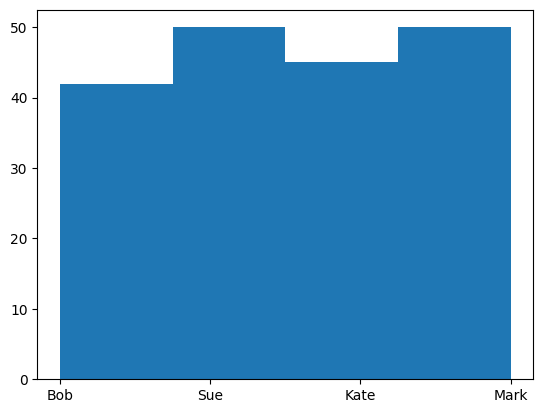

In [ ]:
darts_dataset_url = 'darts-full.csv'

full_data = pd.read_csv(darts_dataset_url)

print(full_data['Competitor'].unique())
plt.hist(full_data['Competitor'], bins=full_data['Competitor'].nunique())
plt.show()

Check the number of unique competitors.

In [ ]:
le = preprocessing.LabelEncoder()
le.fit(full_data['Competitor'])
full_data['Competitor'] = le.transform(full_data['Competitor'])

In [ ]:
print(full_data.head())

    ID    XCoord    YCoord  Competitor
0  111  0.943354 -0.184819           0
1   92  0.121557 -0.927656           0
2   20  0.818485  0.375437           0
3   75  0.867462 -0.159851           3
4   10 -0.817321 -0.373419           1


In [ ]:
le.classes_

array(['Bob', 'Kate', 'Mark', 'Sue'], dtype=object)

Now we check if any of the columns has NULL values.

In [ ]:
# TODO: check to see if any of the columns contain NULL values.

print(full_data.isnull().sum())

ID            0
XCoord        0
YCoord        0
Competitor    0
dtype: int64


In [ ]:
full_data.head()

,ID,XCoord,YCoord,Competitor
0,111,0.943354,-0.184819,0
1,92,0.121557,-0.927656,0
2,20,0.818485,0.375437,0
3,75,0.867462,-0.159851,3
4,10,-0.817321,-0.373419,1


Use train test split to carry out a stratified split, with test size of 25% and random_state=5

In [ ]:
# TODO: split the data into X_train, X_test, y_train, y_test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(full_data[['XCoord', 'YCoord']], full_data['Competitor'],
                                                    stratify=full_data['Competitor'],
                                                    test_size=0.25, random_state=5)

In [ ]:
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

print(len(X_train))
X_train.head()


140


,XCoord,YCoord
0,-0.487382,0.686439
1,-0.675733,0.726966
2,-0.229440,-0.821659
3,-0.138605,0.819174
4,-0.101968,0.093819


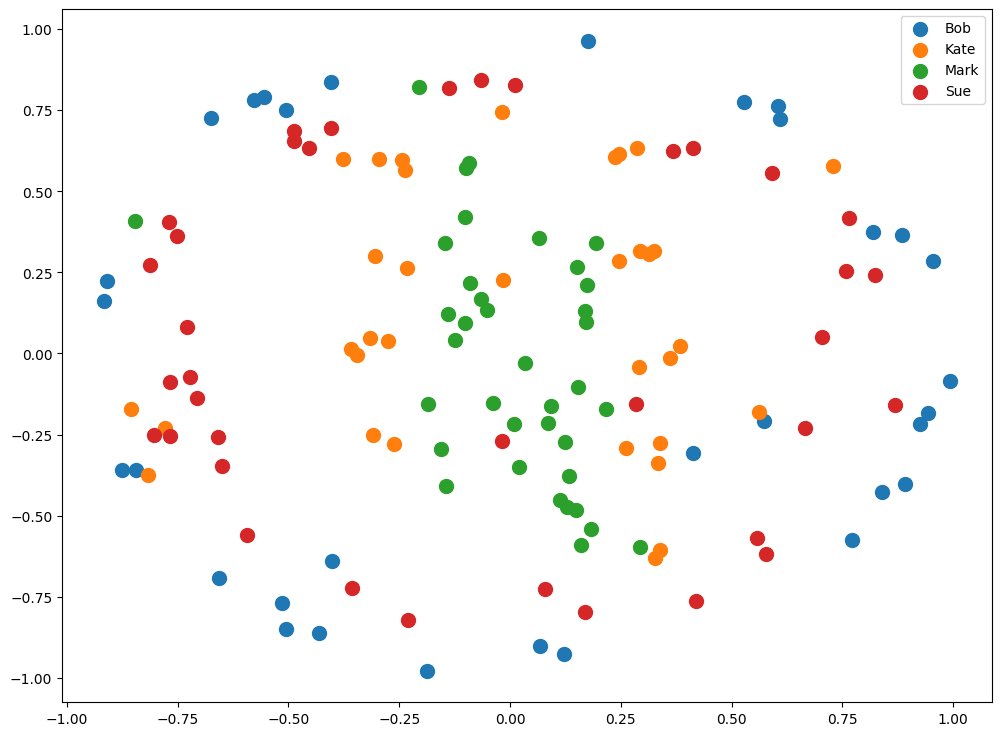

In [ ]:
plt.figure(figsize=(12,9))

for i in range(len(le.classes_)):
  t_indices = list(np.where(y_train == i)[0])
  x_values = X_train.loc[t_indices, ["XCoord"]]
  y_values = X_train.loc[t_indices, ["YCoord"]]

  plt.scatter(x=x_values, y=y_values, s=100)

plt.legend(le.classes_)
plt.show()

#### 9.2 Training baseline models

##### Decision Trees

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

Train a baseline decision tree model and find the accuracy score, and balanced accuracy score. The max_depth can be set as 3.

Save the values as
*   accuracy_baseline_dt
*   balanced_accuracy_baseline_dt

In [ ]:
clf_dt = DecisionTreeClassifier(max_depth=3, random_state=5)
clf_dt.fit(X_train[['XCoord', 'YCoord']], y_train)
y_pred = clf_dt.predict(X_test[['XCoord', 'YCoord']])

accuracy_baseline_dt = accuracy_score(y_test, y_pred)
balanced_accuracy_baseline_dt = balanced_accuracy_score(y_test, y_pred)
print(accuracy_baseline_dt)
print(balanced_accuracy_baseline_dt)

0.46808510638297873
0.4300699300699301


##### Random Forests

Train a baseline random forest model and find the accuracy score, and balanced accuracy score. The max_depth can be set as 3, the number of estimators to be 100, bootstrap to be True oob_score to be True and random state to be 5.

Save the values as
*   accuracy_baseline_rf
*   balanced_accuracy_baseline_rf

In [ ]:
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=5, oob_score = True, bootstrap=True)

clf_rf.fit(X_train[['XCoord', 'YCoord']], y_train)
y_pred = clf_rf.predict(X_test[['XCoord', 'YCoord']])

accuracy_baseline_rf = accuracy_score(y_test, y_pred)
balanced_accuracy_baseline_rf = balanced_accuracy_score(y_test, y_pred)

print(clf_rf.oob_score_)
print(accuracy_baseline_rf)
print(balanced_accuracy_baseline_rf)

0.65
0.6170212765957447
0.5867132867132867


##### XG Classifier

Train a baseline XG classifier model and find the accuracy score, and balanced accuracy score. The max_depth can be set as 3, the number of estimators to be 100, bootstrap to be True and random state to be 5.

Save the values as
*   accuracy_baseline_xg
*   balanced_accuracy_baseline_xg

In [ ]:
clf_xg = XGBClassifier(random_state=5, n_estimators=100, max_depth=3)

clf_xg.fit(X_train[['XCoord', 'YCoord']], y_train)
y_pred = clf_xg.predict(X_test[['XCoord', 'YCoord']])

accuracy_baseline_xg = accuracy_score(y_test, y_pred)
balanced_accuracy_baseline_xg = balanced_accuracy_score(y_test, y_pred)

print(accuracy_baseline_xg)
print(balanced_accuracy_baseline_xg)

0.723404255319149
0.7222027972027971


##### Support Vector Classifier

Train a baseline SVC model and find the accuracy score, and balanced accuracy score. The gamma can be set to auto and random state to be 5.

Save the values as
*   accuracy_baseline_svc
*   balanced_accuracy_baseline_svc

In [ ]:
clf_svm = SVC(gamma='auto', random_state=5)
clf_svm.fit(X_train[['XCoord', 'YCoord']], y_train)
y_pred = clf_svm.predict(X_test[['XCoord', 'YCoord']])

accuracy_baseline_svc = accuracy_score(y_test, y_pred)
balanced_accuracy_baseline_svc = balanced_accuracy_score(y_test, y_pred)

print(accuracy_baseline_svc)
print(balanced_accuracy_baseline_svc)

0.3404255319148936
0.32622377622377624


This next section prints out the accuracy as a table.

In [ ]:
header_list = []
header_list.append(" ")
header_list.append("Decision Tree")
header_list.append("Random Forest")
header_list.append("XG Boost")
header_list.append("SVC")

accuracy_list = []
accuracy_list.append("accuracy baseline")
accuracy_list.append(accuracy_baseline_dt)
accuracy_list.append(accuracy_baseline_rf)
accuracy_list.append(accuracy_baseline_xg)
accuracy_list.append(accuracy_baseline_svc)

balanced_accuracy_list = []
balanced_accuracy_list.append("balanced accuracy baseline")
balanced_accuracy_list.append(balanced_accuracy_baseline_dt)
balanced_accuracy_list.append(balanced_accuracy_baseline_rf)
balanced_accuracy_list.append(balanced_accuracy_baseline_xg)
balanced_accuracy_list.append(balanced_accuracy_baseline_svc)

full_list = []
full_list.append(header_list)
full_list.append(accuracy_list)
full_list.append(balanced_accuracy_list)

df = pd.DataFrame(full_list)
df

,0,1,2,3,4
0,,Decision Tree,Random Forest,XG Boost,SVC
1,accuracy baseline,0.468085,0.617021,0.723404,0.340426
2,balanced accuracy baseline,0.43007,0.586713,0.722203,0.326224


#### 9.3 Simple Feature Engineering

The accuracy that we see above are still relatively low. However it is a common technique to engineer features and some of these engineered features can gastly improve the accuracy scores.

One of the features we will engineer will be the distance from the centre (origin) of the dart board.

Create an additional feature, known as distance. This is the distance from the centre of the dart board. Set this feature to be a new column Distance in full_data dataframe. After that we split into the train and test data again.

In [ ]:
distance = (full_data['XCoord']**2 + full_data['YCoord']**2)**0.5
full_data.loc[:, 'Distance'] = distance

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(full_data[['XCoord', 'YCoord', 'Distance']], full_data['Competitor'],
                                                    stratify=full_data['Competitor'],
                                                    test_size=0.25, random_state=5)

Redo the analysis with Decision Trees, Random Forest, XGBoost and SVC.

Save the Decision Tree accuracies as accuracy_dt and balanced_accuracy_dt.

Save the Random Forest accuracies as accuracy_rf and balanced_accuracy_rf.

Save the XGBoost accuracies as accuracy_xg and balanced_accuracy_xg.

Save the SVC accuracies as accuracy_svc and balanced_accuracy_svc.

In [ ]:
clf_dt = DecisionTreeClassifier(max_depth=3, random_state=5)
clf_dt.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)
y_pred = clf_dt.predict(X_test[['XCoord', 'YCoord', 'Distance']])

accuracy_dt = accuracy_score(y_test, y_pred)
balanced_accuracy_dt = balanced_accuracy_score(y_test, y_pred)
print(accuracy_dt)
print(balanced_accuracy_dt)

0.723404255319149
0.7127622377622378


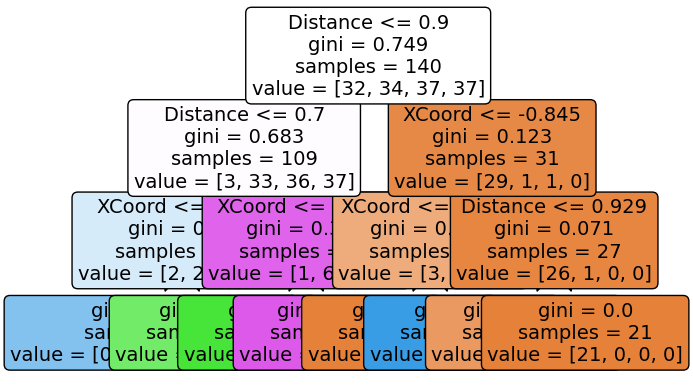

In [ ]:
from sklearn.tree import plot_tree
a = plot_tree(clf_dt, feature_names=['XCoord', 'YCoord', 'Distance'], filled=True,rounded=True,fontsize=14)

In [ ]:
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=5, oob_score = True, bootstrap=True)

clf_rf.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)
y_pred = clf_rf.predict(X_test[['XCoord', 'YCoord', 'Distance']])

accuracy_rf = accuracy_score(y_test, y_pred)
balanced_accuracy_rf = balanced_accuracy_score(y_test, y_pred)

print(clf_rf.oob_score_)
print(accuracy_rf)
print(balanced_accuracy_rf)

0.7928571428571428
0.7659574468085106
0.7687062937062937


The random forest is created through the bootstrap algorithm. When OOB is enabled, it means that you will be using samples not selected via the bootstrap algorithm to calculate the accuracy score.

These are the number of estimators. We can in fact use individual estimators to test if you want.

In [ ]:
len(clf_rf.estimators_)

100

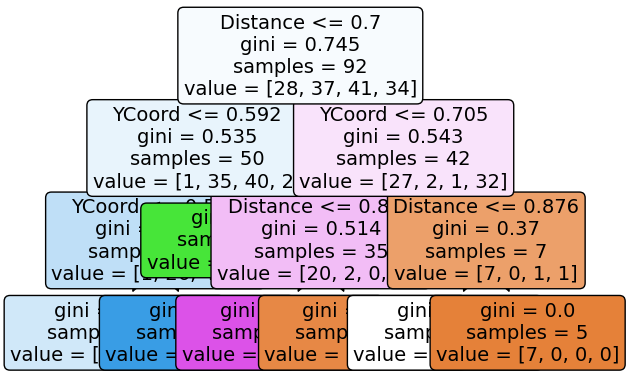

In [ ]:
a = plot_tree(clf_rf.estimators_[0], feature_names=['XCoord', 'YCoord', 'Distance'], filled=True,rounded=True,fontsize=14)

In [ ]:
clf_xg = XGBClassifier(random_state=5, n_estimators=100, max_depth=3)

clf_xg.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)
y_pred = clf_xg.predict(X_test[['XCoord', 'YCoord', 'Distance']])

accuracy_xg = accuracy_score(y_test, y_pred)
balanced_accuracy_xg = balanced_accuracy_score(y_test, y_pred)

print(accuracy_xg)
print(balanced_accuracy_xg)

0.8085106382978723
0.804895104895105


In [ ]:
from sklearn.svm import SVC

clf_svm = SVC(gamma='auto', random_state=5)
clf_svm.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)
y_pred = clf_svm.predict(X_test[['XCoord', 'YCoord', 'Distance']])

accuracy_svc = accuracy_score(y_test, y_pred)
balanced_accuracy_svc = balanced_accuracy_score(y_test, y_pred)

print(accuracy_svc)
print(balanced_accuracy_svc)

0.3829787234042553
0.3646853146853147


In [ ]:
header_list = []
header_list.append(" ")
header_list.append("Decision Tree")
header_list.append("Random Forest")
header_list.append("XG Boost")
header_list.append("SVC")

accuracy_list = []
accuracy_list.append("accuracy baseline")
accuracy_list.append(accuracy_baseline_dt)
accuracy_list.append(accuracy_baseline_rf)
accuracy_list.append(accuracy_baseline_xg)
accuracy_list.append(accuracy_baseline_svc)

balanced_accuracy_list = []
balanced_accuracy_list.append("balanced accuracy baseline")
balanced_accuracy_list.append(balanced_accuracy_baseline_dt)
balanced_accuracy_list.append(balanced_accuracy_baseline_rf)
balanced_accuracy_list.append(balanced_accuracy_baseline_xg)
balanced_accuracy_list.append(balanced_accuracy_baseline_svc)

full_list = []
full_list.append(header_list)
full_list.append(accuracy_list)
full_list.append(balanced_accuracy_list)

df = pd.DataFrame(full_list)
df

,0,1,2,3,4
0,,Decision Tree,Random Forest,XG Boost,SVC
1,accuracy baseline,0.468085,0.617021,0.723404,0.340426
2,balanced accuracy baseline,0.43007,0.586713,0.722203,0.326224


In [ ]:
header_list = []
header_list.append(" ")
header_list.append("Decision Tree")
header_list.append("Random Forest")
header_list.append("XG Boost")
header_list.append("SVC")

accuracy_baseline_list = []
accuracy_baseline_list.append("accuracy baseline")
accuracy_baseline_list.append(accuracy_baseline_dt)
accuracy_baseline_list.append(accuracy_baseline_rf)
accuracy_baseline_list.append(accuracy_baseline_xg)
accuracy_baseline_list.append(accuracy_baseline_svc)

balanced_accuracy_baseline_list = []
balanced_accuracy_baseline_list.append("balanced accuracy baseline")
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_dt)
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_rf)
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_xg)
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_svc)

accuracy_list = []
accuracy_list.append("accuracy")
accuracy_list.append(accuracy_dt)
accuracy_list.append(accuracy_rf)
accuracy_list.append(accuracy_xg)
accuracy_list.append(accuracy_svc)

balanced_accuracy_list = []
balanced_accuracy_list.append("balanced accuracy")
balanced_accuracy_list.append(balanced_accuracy_dt)
balanced_accuracy_list.append(balanced_accuracy_rf)
balanced_accuracy_list.append(balanced_accuracy_xg)
balanced_accuracy_list.append(balanced_accuracy_svc)

full_list = []
full_list.append(header_list)
full_list.append(balanced_accuracy_list)
full_list.append(balanced_accuracy_baseline_list)
full_list.append(accuracy_list)
full_list.append(accuracy_baseline_list)

df = pd.DataFrame(full_list)
df

,0,1,2,3,4
0,,Decision Tree,Random Forest,XG Boost,SVC
1,balanced accuracy,0.712762,0.768706,0.804895,0.364685
2,balanced accuracy baseline,0.43007,0.586713,0.722203,0.326224
3,accuracy,0.723404,0.765957,0.808511,0.382979
4,accuracy baseline,0.468085,0.617021,0.723404,0.340426


In [ ]:
!pip install mlxtend

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


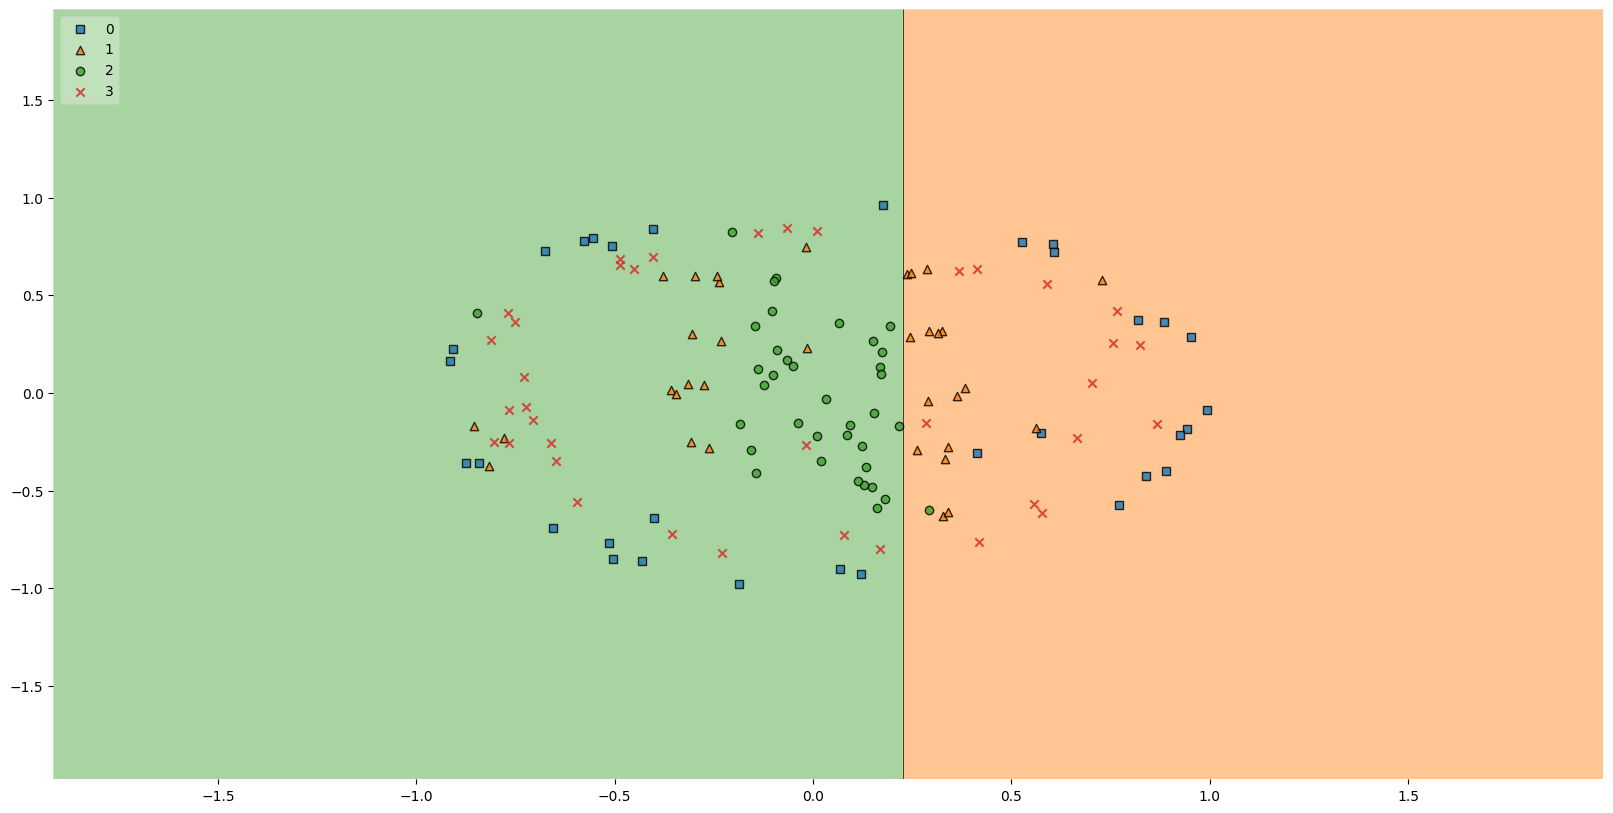

In [ ]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(20,10))
plot_decision_regions(X_train[['XCoord', 'YCoord', 'Distance']].to_numpy(), y_train.to_numpy(), clf_dt,
                      filler_feature_values={2: 0.5},
                      filler_feature_ranges={2: 0.5},
                      legend=2)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


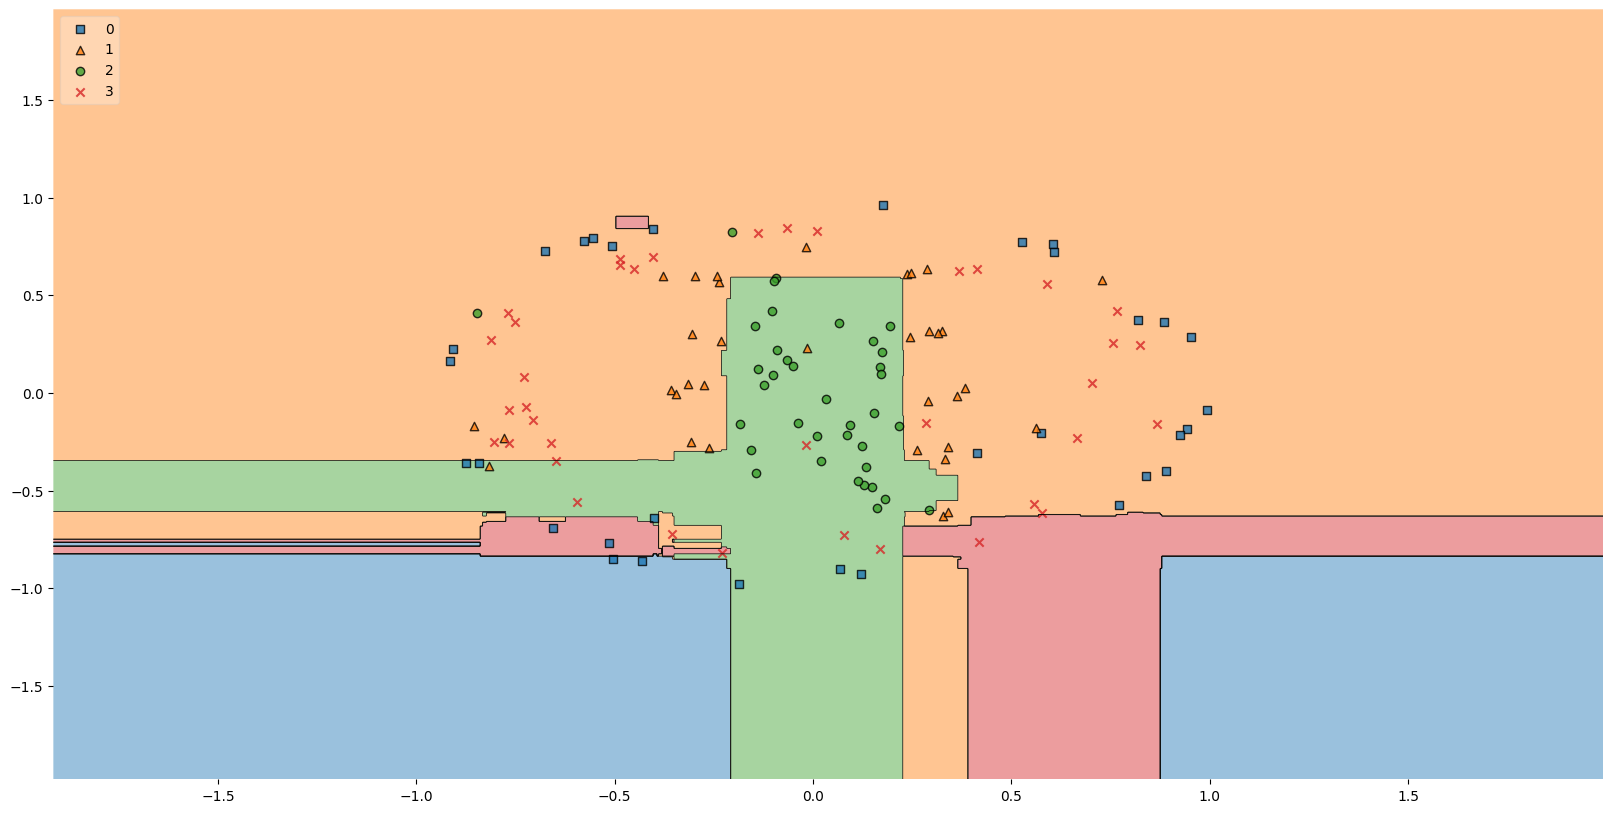

In [ ]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(20,10))
plot_decision_regions(X_train[['XCoord', 'YCoord', 'Distance']].to_numpy(), y_train.to_numpy(), clf_rf,
                      filler_feature_values={2: 0.5},
                      filler_feature_ranges={2: 0.5},
                      legend=2)
plt.show()

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


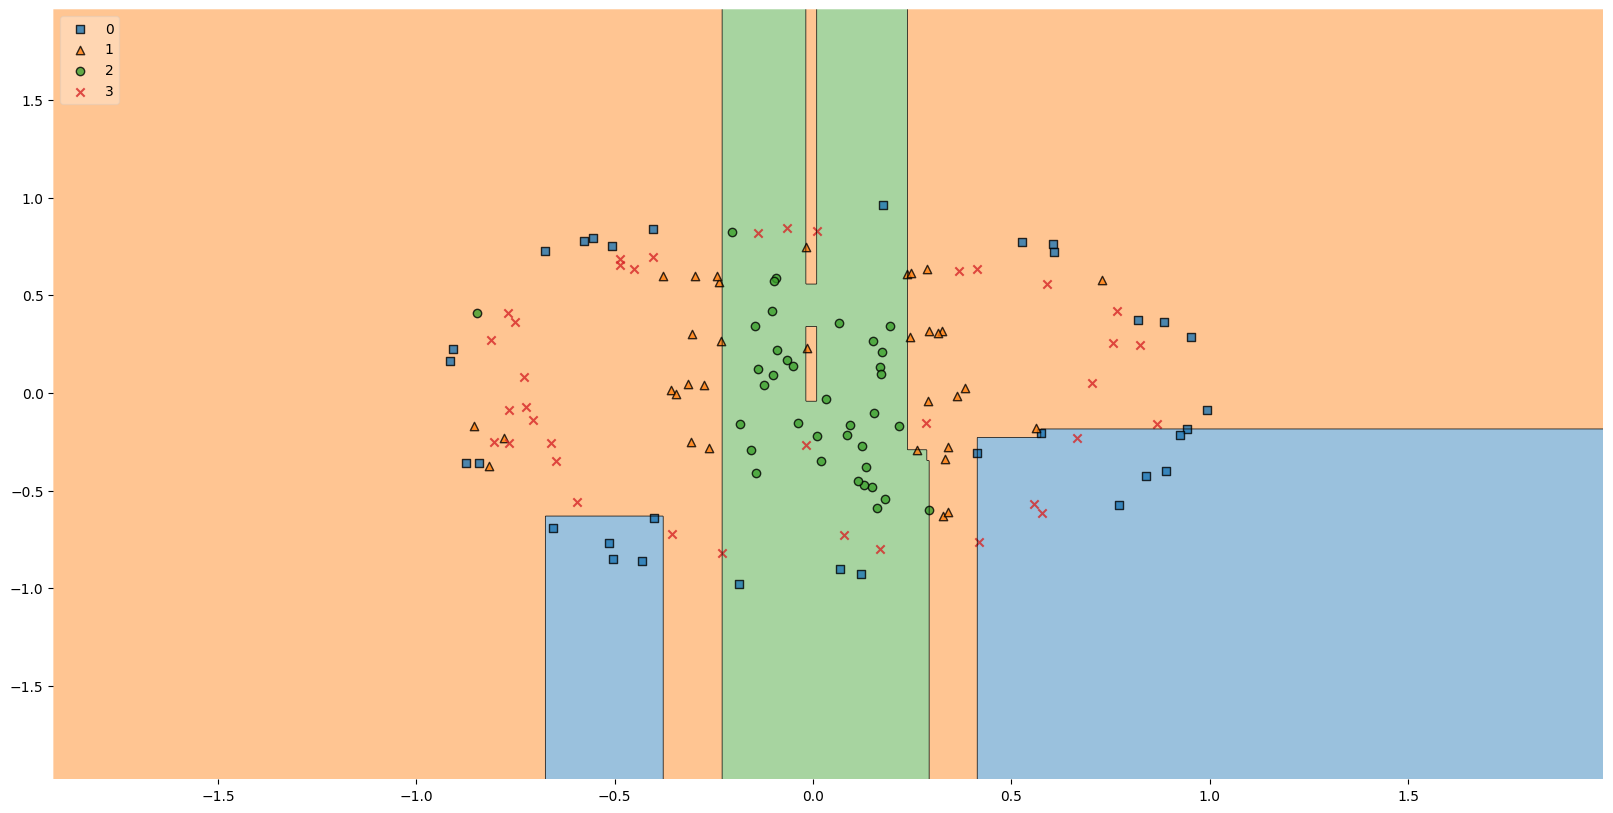

In [ ]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(20,10))
plot_decision_regions(X_train[['XCoord', 'YCoord', 'Distance']].to_numpy(), y_train.to_numpy(), clf_xg,
                      filler_feature_values={2: 0.5},
                      filler_feature_ranges={2: 0.5},
                      legend=2)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define the base estimators
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=3)), # Best params from GridSearch
    ('xgb', XGBClassifier(n_estimators=100, max_depth=7, random_state=5)),
    ('svc', SVC(C=1000, gamma=1, kernel='rbf', probability=True))
]

# Build the stacking classifier
clf_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

clf_stack.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)
y_pred_stack = clf_stack.predict(X_test[['XCoord', 'YCoord', 'Distance']])

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))

Stacking Accuracy: 0.8297872340425532


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


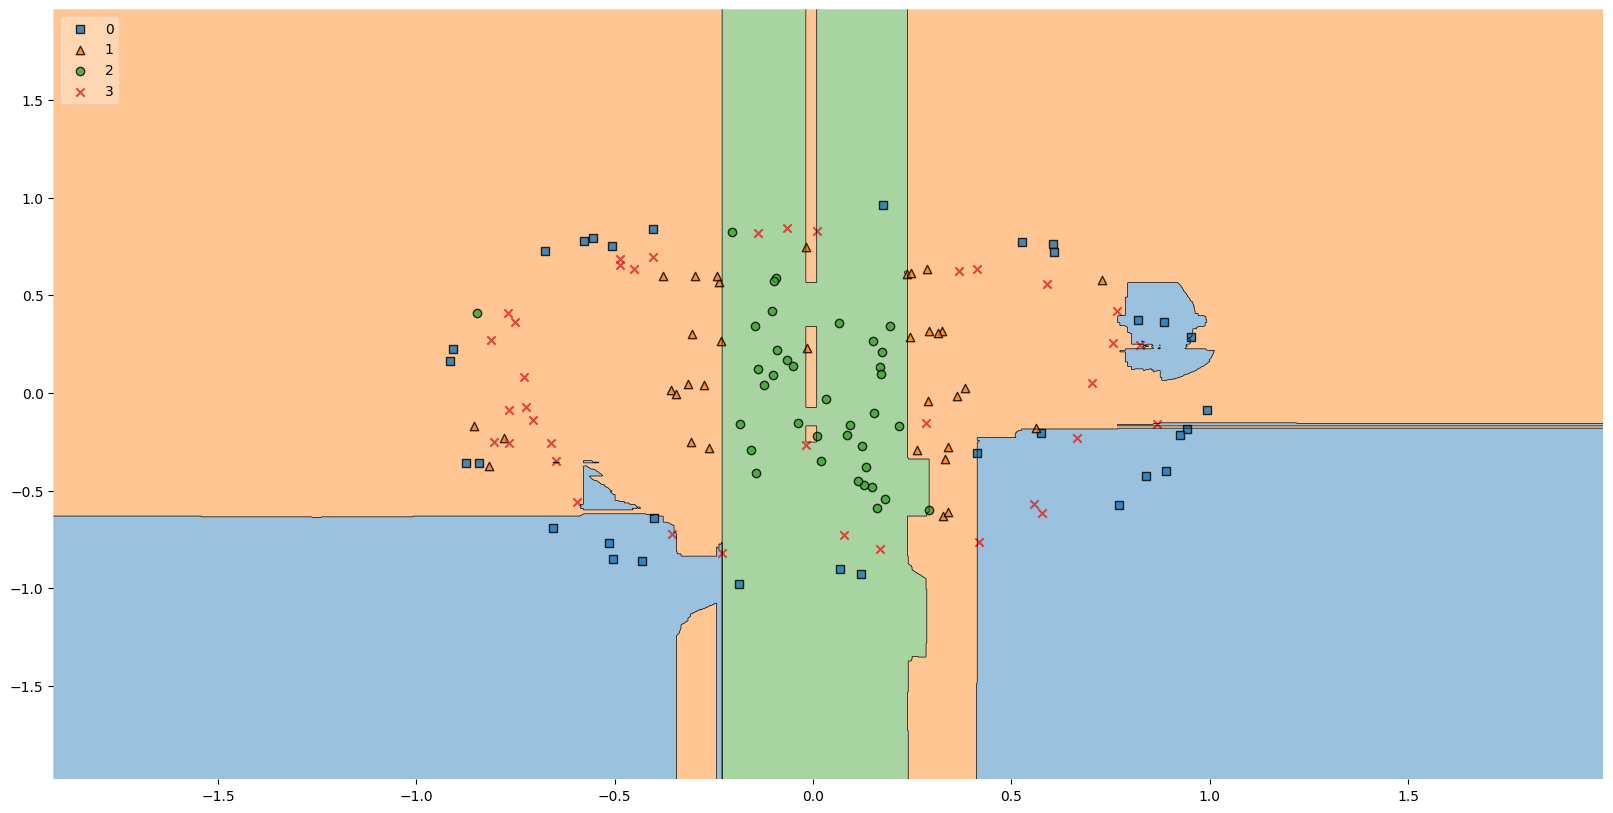

In [ ]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(20,10))
plot_decision_regions(X_train[['XCoord', 'YCoord', 'Distance']].to_numpy(), y_train.to_numpy(), clf_stack,
                      filler_feature_values={2: 0.5},
                      filler_feature_ranges={2: 0.5},
                      legend=2)
plt.show()

In [ ]:
import pandas as pd

# 1. Extract the trained Logistic Regression meta-learner
meta_learner = clf_stack.final_estimator_

# 2. Extract the learned coefficients (weights)
# Shape will be (4 classes, 12 features) because 3 models output 4 probabilities each
weights = meta_learner.coef_

# 3. Reconstruct the feature names for clarity
model_names = ['rf', 'xgb', 'svc']
competitor_classes = le.classes_  # ['Bob', 'Kate', 'Mark', 'Sue']

feature_names = []
for model in model_names:
    for comp in competitor_classes:
        feature_names.append(f"{model}_prob_{comp}")

# 4. Create a DataFrame to view the weight matrix
weights_df = pd.DataFrame(
    weights,
    columns=feature_names,
    index=[f"Meta_Predicts_{comp}" for comp in competitor_classes]
)

print("Meta-Learner Coefficient Matrix:")
display(weights_df)

Meta-Learner Coefficient Matrix:


,rf_prob_Bob,rf_prob_Kate,rf_prob_Mark,rf_prob_Sue,xgb_prob_Bob,xgb_prob_Kate,xgb_prob_Mark,xgb_prob_Sue,svc_prob_Bob,svc_prob_Kate,svc_prob_Mark,svc_prob_Sue
Meta_Predicts_Bob,1.165419,-0.424546,-0.571595,-0.173306,1.487787,0.132283,-0.732840,-0.891258,0.225341,-0.028690,-0.423836,0.223156
Meta_Predicts_Kate,-0.477326,0.899144,-0.030709,-0.381508,-0.200369,0.895562,-0.826219,0.140628,-0.192957,0.579844,0.483976,-0.861262
Meta_Predicts_Mark,-0.272398,-0.182196,1.099586,-0.648508,-0.478403,-0.738612,1.797601,-0.584102,-0.123142,-0.207437,0.264722,0.062340
Meta_Predicts_Sue,-0.415694,-0.292402,-0.497281,1.203322,-0.809015,-0.289232,-0.238541,1.334733,0.090757,-0.343717,-0.324861,0.575766


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Define the base estimators (same as before)
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=3, random_state=5)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=7, random_state=5)),
    ('svc', SVC(C=1000, gamma=1, kernel='rbf', probability=True, random_state=5))
]

# 2. Build the Regionally-Aware Stacking Classifier
# We use a shallow Decision Tree to prevent massive overfitting
clf_stack_regional = StackingClassifier(
    estimators=estimators,
    final_estimator=DecisionTreeClassifier(max_depth=3, random_state=5),
    passthrough=True # CRITICAL: Passes XCoord, YCoord, Distance to the meta-learner
)

# 3. Train and Evaluate
clf_stack_regional.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)
y_pred_regional = clf_stack_regional.predict(X_test[['XCoord', 'YCoord', 'Distance']])

print("Regional Stacking Accuracy:", accuracy_score(y_test, y_pred_regional))

Regional Stacking Accuracy: 0.8085106382978723


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


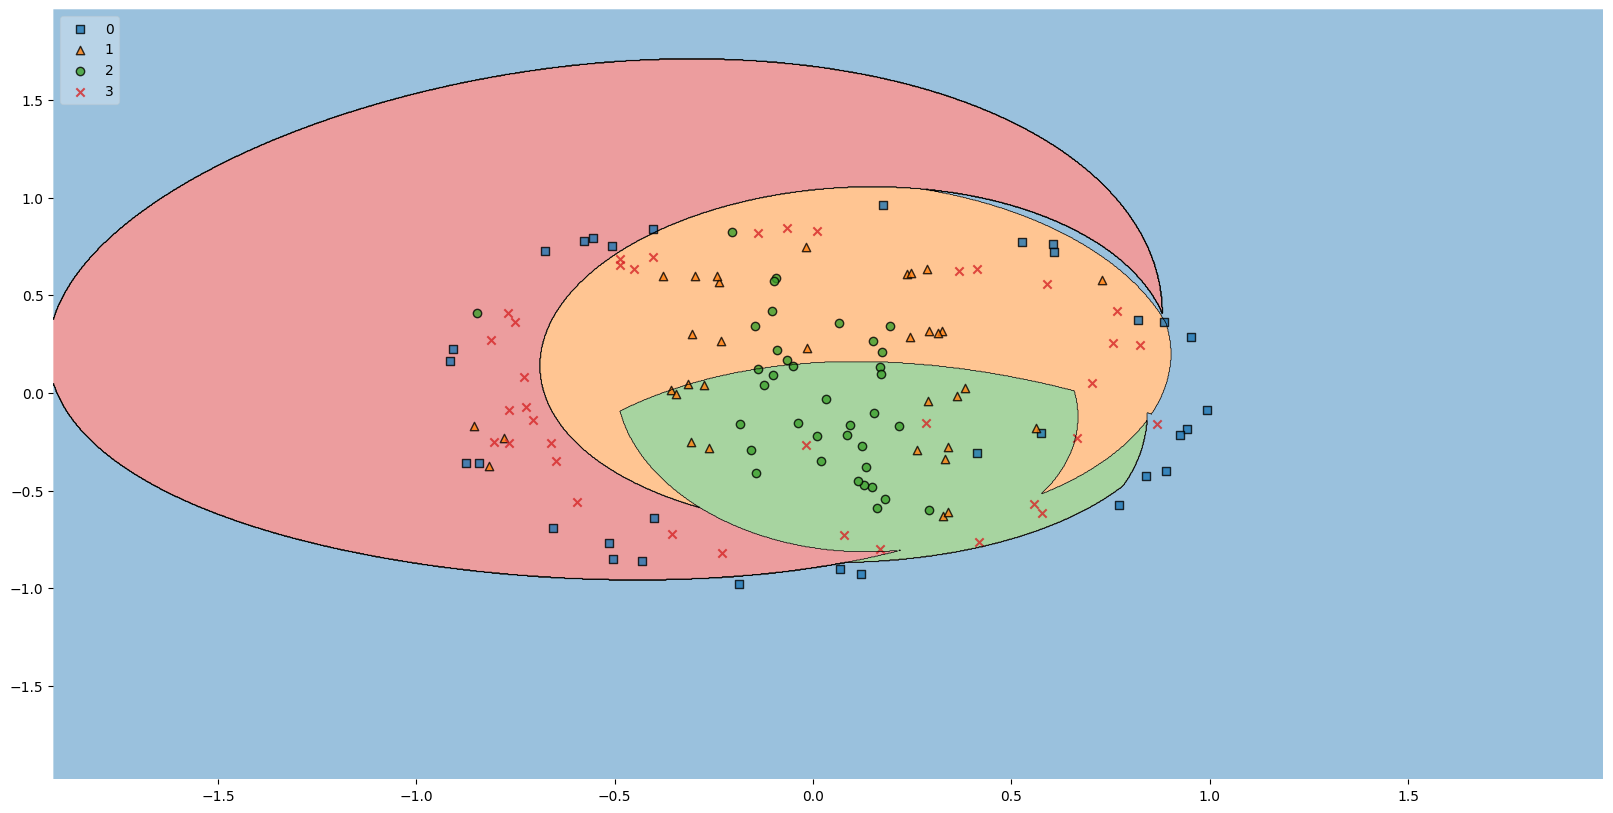

In [ ]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(20,10))
plot_decision_regions(X_train[['XCoord', 'YCoord', 'Distance']].to_numpy(), y_train.to_numpy(), clf_svm,
                      filler_feature_values={2: 0.5},
                      filler_feature_ranges={2: 0.5},
                      legend=2)
plt.show()

#### 9.4 Introduction to Hyperparameter Tuning

This is a brute force search to find the best set of parameters for a model. We try to fit various permutations of the parameters to find the best set of parameters which optimize the accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
clf_dt = DecisionTreeClassifier(max_depth=3, random_state=5)

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [2, 3, 4],
    'min_samples_split': [8, 10, 12],
}

# Instantiate the grid search model
clf_rf_grid = GridSearchCV(estimator = clf_dt, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2)
clf_rf_grid.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)

y_pred = clf_rf_grid.predict(X_test[['XCoord', 'YCoord', 'Distance']])
accuracy_grid_dt = accuracy_score(y_test, y_pred)
balanced_accuracy_grid_dt = balanced_accuracy_score(y_test, y_pred)

print(accuracy_grid_dt)
print(balanced_accuracy_grid_dt)

Fitting 3 folds for each of 63 candidates, totalling 189 fits
0.851063829787234
0.8618881118881119


In [ ]:
clf_rf_grid.best_params_

{'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 12}

Redo the analysis with Random Forest, XGBoost and SVC.

Save the Random Forest accuracies as accuracy_grid_rf and balanced_accuracy_grid_rf.




```
# random forest parameters
param_grid = {
    'bootstrap': [True],
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [2, 3, 4],
    'min_samples_split': [8, 10, 12],
    'n_estimators': [100, 200, 300]
}
```

Save the XGBoost accuracies as accuracy_grid_xg and balanced_accuracy_grid_xg.

```
param_grid = {
    'max_depth': [2,3,4,5,6,7,8],
    'n_estimators': [100, 200, 300]
}
```

Save the SVC accuracies as accuracy_grid_svc and balanced_accuracy_grid_svc.



```
param_grid = {
              'C':[1,10,100,1000],
              'gamma':[1,0.1,0.001,0.0001],
              'kernel':['linear','rbf']
            }
```




In [ ]:
clf_rf = RandomForestClassifier(n_estimators=100, oob_score = True, bootstrap=True)

# Create the parameter grid based on the results of random search
param_grid = {
    'bootstrap': [True],
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [2, 3, 4],
    'min_samples_split': [8, 10, 12],
    'n_estimators': [100, 200, 300]
}

# Instantiate the grid search model
clf_rf_grid = GridSearchCV(estimator = clf_rf, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2)
clf_rf_grid.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)

y_pred = clf_rf_grid.predict(X_test[['XCoord', 'YCoord', 'Distance']])
accuracy_grid_rf = accuracy_score(y_test, y_pred)
balanced_accuracy_grid_rf = balanced_accuracy_score(y_test, y_pred)

print(accuracy_grid_rf)
print(balanced_accuracy_grid_rf)

Fitting 3 folds for each of 189 candidates, totalling 567 fits
0.8085106382978723
0.8141608391608391


Print out the best parameters for the rf grid search model.

In [ ]:
clf_rf_grid.best_params_

{'bootstrap': True,
 'max_depth': 5,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 100}

In [ ]:
clf_xg = XGBClassifier(random_state=5, n_estimators=100, max_depth=3)

# Create the parameter grid based on the results of random search
param_grid = {
    'max_depth': [2,3,4,5,6,7,8],
    'n_estimators': [100, 200, 300]
}

# Instantiate the grid search model
clf_xg_grid = GridSearchCV(estimator = clf_rf, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2)
clf_xg_grid.fit(X_train[['XCoord', 'YCoord', 'Distance']], y_train)

y_pred = clf_xg_grid.predict(X_test[['XCoord', 'YCoord', 'Distance']])
accuracy_grid_xg = accuracy_score(y_test, y_pred)
balanced_accuracy_grid_xg = balanced_accuracy_score(y_test, y_pred)

print(accuracy_grid_xg)
print(balanced_accuracy_grid_xg)

Fitting 3 folds for each of 21 candidates, totalling 63 fits
0.7872340425531915
0.7914335664335664


Print out the best parameters for the xgboost grid search model.

In [ ]:
clf_xg_grid.best_params_

{'max_depth': 4, 'n_estimators': 100}

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[1,10,100,1000],'gamma':[1,0.1,0.001,0.0001], 'kernel':['linear','rbf']}
clf_svc_grid = GridSearchCV(SVC(random_state=0), param_grid, refit = True, cv=5, verbose=0)
clf_svc_grid.fit(X_train[['XCoord', 'YCoord', 'Distance']],y_train)

y_pred = clf_svc_grid.predict(X_test[['XCoord', 'YCoord', 'Distance']])
accuracy_grid_svc = accuracy_score(y_test, y_pred)
balanced_accuracy_grid_svc = balanced_accuracy_score(y_test, y_pred)

print(accuracy_grid_svc)
print(balanced_accuracy_grid_svc)

0.6170212765957447
0.612062937062937


Print out the best parameters for the svc grid search model.

In [ ]:
clf_svc_grid.best_params_

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
header_list = []
header_list.append(" ")
header_list.append("Decision Tree")
header_list.append("Random Forest")
header_list.append("XG Boost")
header_list.append("SVC")

accuracy_baseline_list = []
accuracy_baseline_list.append("accuracy baseline")
accuracy_baseline_list.append(accuracy_baseline_dt)
accuracy_baseline_list.append(accuracy_baseline_rf)
accuracy_baseline_list.append(accuracy_baseline_xg)
accuracy_baseline_list.append(accuracy_baseline_svc)

balanced_accuracy_baseline_list = []
balanced_accuracy_baseline_list.append("balanced accuracy baseline")
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_dt)
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_rf)
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_xg)
balanced_accuracy_baseline_list.append(balanced_accuracy_baseline_svc)

accuracy_list = []
accuracy_list.append("accuracy")
accuracy_list.append(accuracy_dt)
accuracy_list.append(accuracy_rf)
accuracy_list.append(accuracy_xg)
accuracy_list.append(accuracy_svc)

balanced_accuracy_list = []
balanced_accuracy_list.append("balanced accuracy")
balanced_accuracy_list.append(balanced_accuracy_dt)
balanced_accuracy_list.append(balanced_accuracy_rf)
balanced_accuracy_list.append(balanced_accuracy_xg)
balanced_accuracy_list.append(balanced_accuracy_svc)

accuracy_grid_list = []
accuracy_grid_list.append("accuracy grid")
accuracy_grid_list.append(accuracy_grid_dt)
accuracy_grid_list.append(accuracy_grid_rf)
accuracy_grid_list.append(accuracy_grid_xg)
accuracy_grid_list.append(accuracy_grid_svc)

balanced_accuracy_grid_list = []
balanced_accuracy_grid_list.append("balanced accuracy grid")
balanced_accuracy_grid_list.append(balanced_accuracy_grid_dt)
balanced_accuracy_grid_list.append(balanced_accuracy_grid_rf)
balanced_accuracy_grid_list.append(balanced_accuracy_grid_xg)
balanced_accuracy_grid_list.append(balanced_accuracy_grid_svc)


full_list = []
full_list.append(header_list)
full_list.append(accuracy_grid_list)
full_list.append(balanced_accuracy_grid_list)
full_list.append(balanced_accuracy_list)
full_list.append(balanced_accuracy_baseline_list)
full_list.append(accuracy_list)
full_list.append(accuracy_baseline_list)

df = pd.DataFrame(full_list)
df

,0,1,2,3,4
0,,Decision Tree,Random Forest,XG Boost,SVC
1,accuracy grid,0.851064,0.808511,0.787234,0.617021
2,balanced accuracy grid,0.861888,0.814161,0.791434,0.612063
3,balanced accuracy,0.712762,0.768706,0.804895,0.364685
4,balanced accuracy baseline,0.43007,0.586713,0.722203,0.326224
5,accuracy,0.723404,0.765957,0.808511,0.382979
6,accuracy baseline,0.468085,0.617021,0.723404,0.340426
